# Understanding Masculine Identity

**Hanif Musaheb, Sara Chanaa, Luke Reiter**


## Introduction

Our team investigated masculinity using a dataset based off of a “masculinity survey” that asked 30 questions to men that are older than 18. This dataset was provided to the team via BrightSpace and while it does not say who ran this survey, and who gathered the data, our team believes it is trustworthy due to our professor posting and being confident in this data.

There is potential for bias in this data, as we also do not know who participated in this survey, but in the end our team thinks that it is a relatively true representation of men above the age of 18.

The data collected is mostly categorical variables, since respondents selected from a set range of answers. This limits some of the tests that can be run, but it still allows us to draw conclusions by cleaning the data, exploring patterns, and applying machine learning methods.

## Research Question

How does family affect a male's perception of masculinity?

More specifically, we examine whether respondents who identify fathers, mothers, or other family members as important influences report different levels of self-perceived masculinity.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

## Loading the Data

We begin by loading the survey data and inspecting its structure. This helps us understand the available variables, their formatting, and any missing values that need to be handled.

In [2]:
df = pd.read_csv("masculinity_survey.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1615, 98)


,Unnamed: 0,StartDate,EndDate,q0001,q0002,q0004_0001,q0004_0002,q0004_0003,q0004_0004,q0004_0005,...,q0035,q0036,race2,racethn4,educ3,educ4,age3,kids,orientation,weight
0,1,5/10/18 4:01,5/10/18 4:06,Somewhat masculine,Somewhat important,Not selected,Not selected,Not selected,Pop culture,Not selected,...,Middle Atlantic,Windows Desktop / Laptop,Non-white,Hispanic,College or more,College or more,35 - 64,No children,Gay/Bisexual,1.714026
1,2,5/10/18 6:30,5/10/18 6:53,Somewhat masculine,Somewhat important,Father or father figure(s),Not selected,Not selected,Not selected,Not selected,...,East North Central,iOS Phone / Tablet,White,White,Some college,Some college,65 and up,Has children,Straight,1.247120
2,3,5/10/18 7:02,5/10/18 7:09,Very masculine,Not too important,Father or father figure(s),Not selected,Not selected,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,College or more,College or more,35 - 64,Has children,Straight,0.515746
3,4,5/10/18 7:27,5/10/18 7:31,Very masculine,Not too important,Father or father figure(s),Mother or mother figure(s),Other family members,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,Some college,Some college,65 and up,Has children,No answer,0.600640
4,5,5/10/18 7:35,5/10/18 7:42,Very masculine,Very important,Not selected,Not selected,Other family members,Not selected,Not selected,...,East North Central,Windows Desktop / Laptop,White,White,College or more,College or more,35 - 64,No children,Straight,1.033400


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1615 entries, 0 to 1614
Data columns (total 98 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   1615 non-null   int64  
 1   StartDate    1615 non-null   object 
 2   EndDate      1615 non-null   object 
 3   q0001        1615 non-null   object 
 4   q0002        1615 non-null   object 
 5   q0004_0001   1615 non-null   object 
 6   q0004_0002   1615 non-null   object 
 7   q0004_0003   1615 non-null   object 
 8   q0004_0004   1615 non-null   object 
 9   q0004_0005   1615 non-null   object 
 10  q0004_0006   1615 non-null   object 
 11  q0005        1615 non-null   object 
 12  q0007_0001   1615 non-null   object 
 13  q0007_0002   1615 non-null   object 
 14  q0007_0003   1615 non-null   object 
 15  q0007_0004   1615 non-null   object 
 16  q0007_0005   1615 non-null   object 
 17  q0007_0006   1615 non-null   object 
 18  q0007_0007   1615 non-null   object 
 19  q0007_

In [4]:
df.isna().sum().sort_values(ascending=False).head(20)

q0013         1566
q0015          873
q0012_0001     735
q0011_0002     735
q0010_0001     735
q0010_0002     735
q0010_0003     735
q0010_0004     735
q0010_0005     735
q0010_0006     735
q0010_0007     735
q0010_0008     735
q0011_0001     735
q0011_0003     735
q0011_0004     735
q0011_0005     735
q0012_0002     735
q0012_0003     735
q0012_0004     735
q0012_0005     735
dtype: int64

## Data Description

The dataset is made up mostly of categorical survey responses. Respondents selected answers from fixed categories, meaning most variables are non-numeric.

During our review of the dataset, we noticed:

- Some variables fall outside the scope of our project.
- Some multiple-choice questions are split across many columns.
- Many columns use `"Not selected"` for unchosen responses.
- Some questions only appear conditionally, creating missing values.
- Some columns appear redundant.

Because of this, cleaning and restructuring are necessary before analysis.

In [5]:
print(df.columns.tolist())

['Unnamed: 0', 'StartDate', 'EndDate', 'q0001', 'q0002', 'q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006', 'q0005', 'q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004', 'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009', 'q0007_0010', 'q0007_0011', 'q0008_0001', 'q0008_0002', 'q0008_0003', 'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008', 'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012', 'q0009', 'q0010_0001', 'q0010_0002', 'q0010_0003', 'q0010_0004', 'q0010_0005', 'q0010_0006', 'q0010_0007', 'q0010_0008', 'q0011_0001', 'q0011_0002', 'q0011_0003', 'q0011_0004', 'q0011_0005', 'q0012_0001', 'q0012_0002', 'q0012_0003', 'q0012_0004', 'q0012_0005', 'q0012_0006', 'q0012_0007', 'q0013', 'q0014', 'q0015', 'q0017', 'q0018', 'q0019_0001', 'q0019_0002', 'q0019_0003', 'q0019_0004', 'q0019_0005', 'q0019_0006', 'q0019_0007', 'q0020_0001', 'q0020_0002', 'q0020_0003', 'q0020_0004', 'q0020_0005', 'q0020_0006', 'q0021_0001'

## Cleaning the Data

To focus on our research question, we keep the variables most relevant to masculinity perception and family influence.

We focus mainly on:

- `q0001`: self-perception of masculinity  
- `q0004_0001`: father or father figure(s)  
- `q0004_0002`: mother or mother figure(s)  
- `q0004_0003`: other family members  

We also remove unnecessary columns such as timestamps and the unnamed index column.

In [6]:
columns_to_drop = ["Unnamed: 0", "StartDate", "EndDate"]

df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors="ignore")

print("New shape:", df_clean.shape)

New shape: (1615, 95)


## Converting Family Variables to Binary Format

The family influence variables are stored as multiple-choice columns where selected responses contain text and unselected responses contain `"Not selected"`.

We convert these to:

- `1` = selected  
- `0` = not selected

In [7]:
family_cols = ["q0004_0001", "q0004_0002", "q0004_0003"]

for col in family_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip().lower() == "not selected" else 1
    )

df_clean[family_cols].head()

,q0004_0001,q0004_0002,q0004_0003
0,0,0,0
1,1,0,0
2,1,0,0
3,1,1,1
4,0,0,1


## Encoding Masculinity Perception

We convert the self-perception masculinity question into an ordinal numeric scale:

- `4` = Very masculine  
- `3` = Somewhat masculine  
- `2` = Not very masculine  
- `1` = Not at all masculine  

Responses marked `"No answer"` are treated as missing values.

In [8]:
masculinity_mapping = {
    "Very masculine": 4,
    "Somewhat masculine": 3,
    "Not very masculine": 2,
    "Not at all masculine": 1,
    "No answer": np.nan
}

df_clean["Q1_score"] = df_clean["q0001"].map(masculinity_mapping)

df_clean[["q0001", "Q1_score"]].head()

,q0001,Q1_score
0,Somewhat masculine,3.0
1,Somewhat masculine,3.0
2,Very masculine,4.0
3,Very masculine,4.0
4,Very masculine,4.0


In [9]:
df_clean["Q1_score"].value_counts(dropna=False).sort_index()

Q1_score
1.0     32
2.0    131
3.0    826
4.0    612
NaN     14
Name: count, dtype: int64

## Exploratory Data Analysis

Our exploratory analysis focuses on family influence. We examine whether respondents who selected father figures, mother figures, or other family members as important influences report different masculinity self-ratings.

Because father influence appears most frequently in the dataset, it serves as a useful starting point for the analysis.

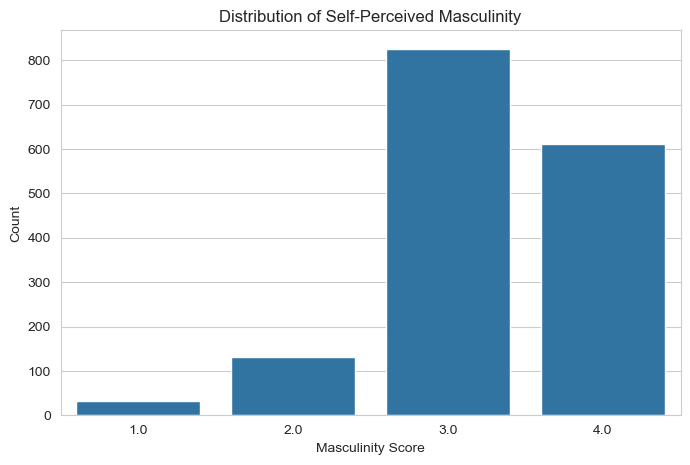

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score")
plt.title("Distribution of Self-Perceived Masculinity")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.show()

In [11]:
father_pct = df_clean["q0004_0001"].mean() * 100
mother_pct = df_clean["q0004_0002"].mean() * 100
other_family_pct = df_clean["q0004_0003"].mean() * 100

print(f"Father influence: {father_pct:.1f}%")
print(f"Mother influence: {mother_pct:.1f}%")
print(f"Other family influence: {other_family_pct:.1f}%")

Father influence: 68.7%
Mother influence: 40.6%
Other family influence: 34.9%


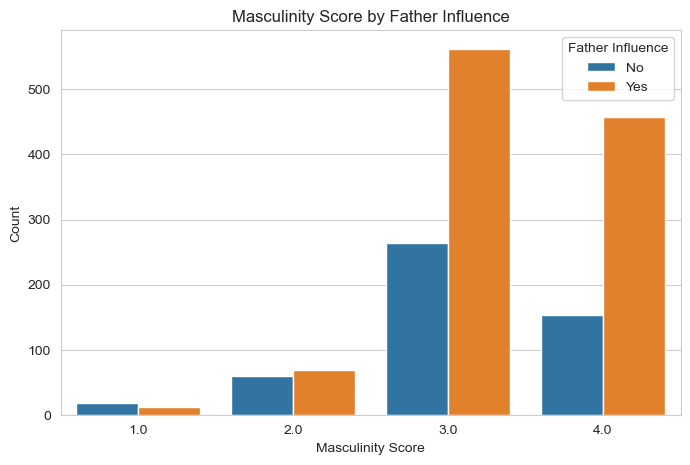

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0001")
plt.title("Masculinity Score by Father Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Father Influence", labels=["No", "Yes"])
plt.show()

Father influence was the strongest family-related variable in our initial review. This graph compares masculinity self-ratings between respondents who selected father influence and those who did not.

In [13]:
df_clean.groupby("q0004_0001")["Q1_score"].mean()

q0004_0001
0    3.110442
1    3.328196
Name: Q1_score, dtype: float64

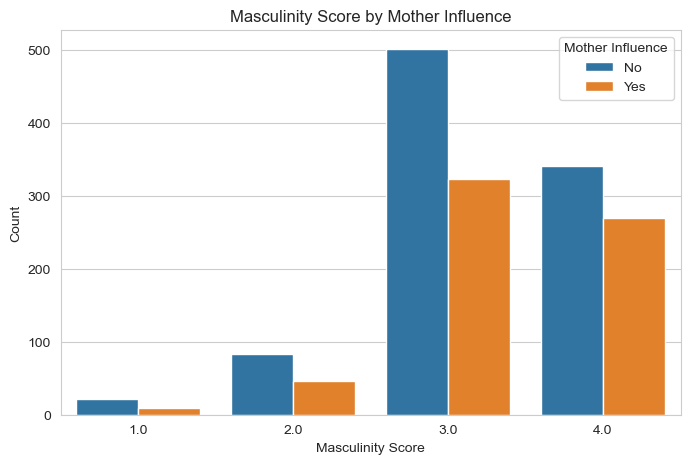

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0002")
plt.title("Masculinity Score by Mother Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Mother Influence", labels=["No", "Yes"])
plt.show()

In [15]:
df_clean.groupby("q0004_0002")["Q1_score"].mean()

q0004_0002
0    3.225263
1    3.311828
Name: Q1_score, dtype: float64

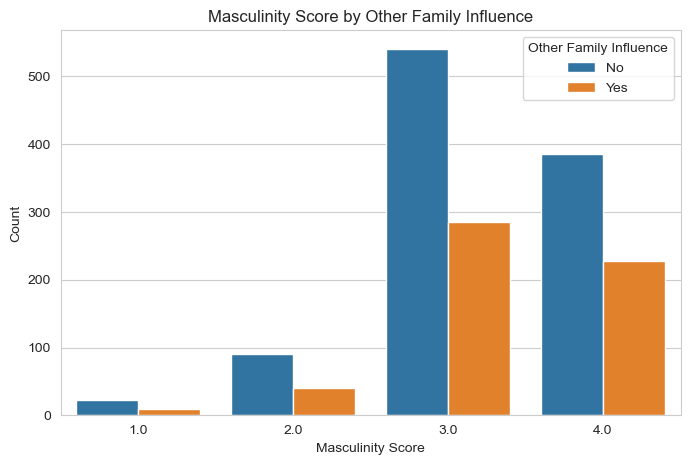

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_clean, x="Q1_score", hue="q0004_0003")
plt.title("Masculinity Score by Other Family Influence")
plt.xlabel("Masculinity Score")
plt.ylabel("Count")
plt.legend(title="Other Family Influence", labels=["No", "Yes"])
plt.show()

In [17]:
df_clean.groupby("q0004_0003")["Q1_score"].mean()

q0004_0003
0    3.238462
1    3.301248
Name: Q1_score, dtype: float64

### Age
Below you can see the distribution of ages in the data, which we believe is important not as a direct measure of someones families but due to this survey being conducted in the the US particepents that are younger are much less likely to have kids of their own and the opposite is true for the older demographics. It will be interesting to see how this data matchs up with how masculine the men surveyed feel.

### Kids
Having children will be a much more direct way to see a surveyed persons family while the data doesn't say anthing specfic about ones family: how big?, divorced?, daughter or sons? It will provide critical data on wether or not they have kids.

### Orientation
I have included this one even though I am not sure how relevent it will be to what the families make up is. However it would be interesting to see if there are any divergences between the difference between a straight man and a straight dad and a gay man and a gay dad. What I am looking for is wether the change of being a father effects the two groups significantly differently.

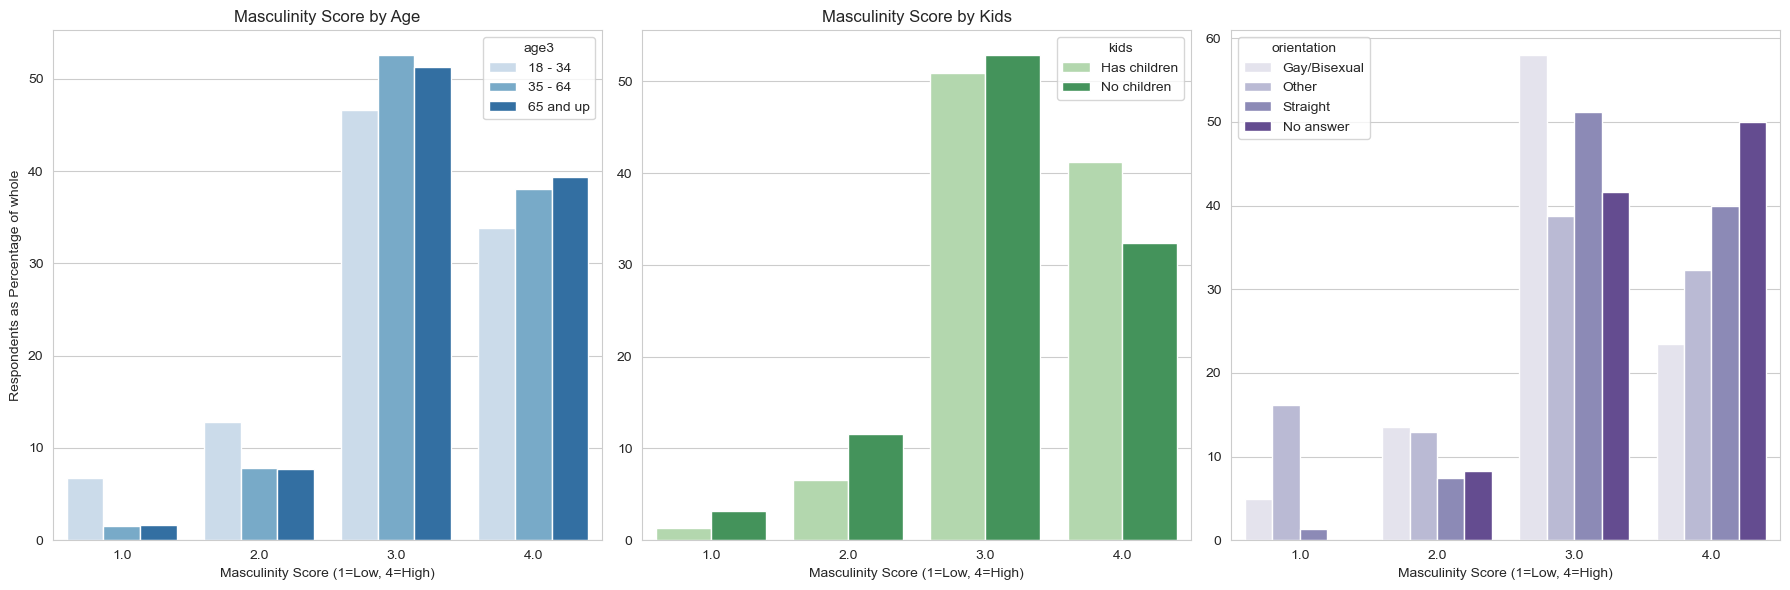

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))# 1x3 for the 3 plots on 1 row and figsize is the dimensions of that

# Age
age_pct = df_clean.groupby('age3')['Q1_score'].value_counts(normalize=True).mul(100).reset_index(name='Percentage')
sns.barplot(data=age_pct, x='Q1_score', y='Percentage', hue='age3', ax=axes[0], palette='Blues')
axes[0].set_title('Masculinity Score by Age')
axes[0].set_xlabel('Masculinity Score (1=Low, 4=High)')
axes[0].set_ylabel('Respondents as Percentage of whole')

# Kids
kids_pct = df_clean.groupby('kids')['Q1_score'].value_counts(normalize=True).mul(100).reset_index(name='Percentage')
sns.barplot(data=kids_pct, x='Q1_score', y='Percentage', hue='kids', ax=axes[1], palette='Greens')
axes[1].set_title('Masculinity Score by Kids')
axes[1].set_xlabel('Masculinity Score (1=Low, 4=High)')
axes[1].set_ylabel('') # Hiding the y label to keep it clean

# Orientation
orientation_pct = df_clean.groupby('orientation')['Q1_score'].value_counts(normalize=True).mul(100).reset_index(name='Percentage')
sns.barplot(data=orientation_pct, x='Q1_score', y='Percentage', hue='orientation', ax=axes[2], palette='Purples')
axes[2].set_xlabel('Masculinity Score (1=Low, 4=High)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Implications of the result above
You can see some trends emergung that may have been predictable before hand. In age it would seem as though you can see that there is a bias that students with a lower age are less likely have to a high masculinity. While older people seem to have higher percentage classifying themselves as more masculine.

Kids again backs this trend up showing a significant but marginal increased rate at classifying themselves as more masculine if the men had kids.

Finally for orientation it is little bit more confusing and it is not clear if there is a significant trend here which serves as useful information going forward with this project to possible not take that into consideration when trying to answer the main question of this project.



### Questions/Columns that are relevent to our question:
- `q1` In general, how masculine or “manly” do you feel? 
- `q2` How important is it to you that others see you as masculine?
- `q4` Where have you gotten your ideas about what it means to be a good man?
- `q7` How often would you say you do each of the following? 
- `q8` Which of the following do you worry about on a daily or near daily basis?
- `q9` Which of the following categories best describes your employment status?

In [19]:
q1=['q0001']
q2=['q0002']
q4=['q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006']
q5=['q0005']
q7=['q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004',
       'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 'q0007_0009',
       'q0007_0010', 'q0007_0011']
q8=['q0008_0001', 'q0008_0002', 'q0008_0003',
       'q0008_0004', 'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008',
       'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012']
q9=['q0009']


In [20]:
def plot_checkbox_percentages(df, question_cols, labels_dict, title, group_col='kids',values_to_drop=["Not selected"]):
    """
    a general function to plot the multiple choice question data to bar graphs
    """
    temp_df = df.copy()# create a copy to not modify original data frame
    temp_df[question_cols] = temp_df[question_cols].replace(values_to_drop, np.nan)  #replace not selected with NAN
    totals_by_group = temp_df[group_col].value_counts()#total population in each demographic
    checked_counts = temp_df.groupby(group_col)[question_cols].count() # count how many people checked each option, grouped by the demographic
    percentages_df = checked_counts.div(totals_by_group, axis=0) * 100 #calculate percentage
    
    # reshape the dataframe for Seaborn
    percentages_df = percentages_df.reset_index() 
    plot_df = percentages_df.melt(id_vars=group_col, var_name='Question', value_name='Percentage')
    
    
    plot_df['Question'] = plot_df['Question'].map(labels_dict)# apply the labels
    

    plt.figure(figsize=(12, 8)) 
    sns.barplot(data=plot_df, x='Percentage', y='Question', hue=group_col, palette='Set2')
    plt.title(title)
    plt.xlabel('Percentage of Demographic Group (%)')
    plt.ylabel('Checkbox Options')
    
    plt.tight_layout()
    plt.show()


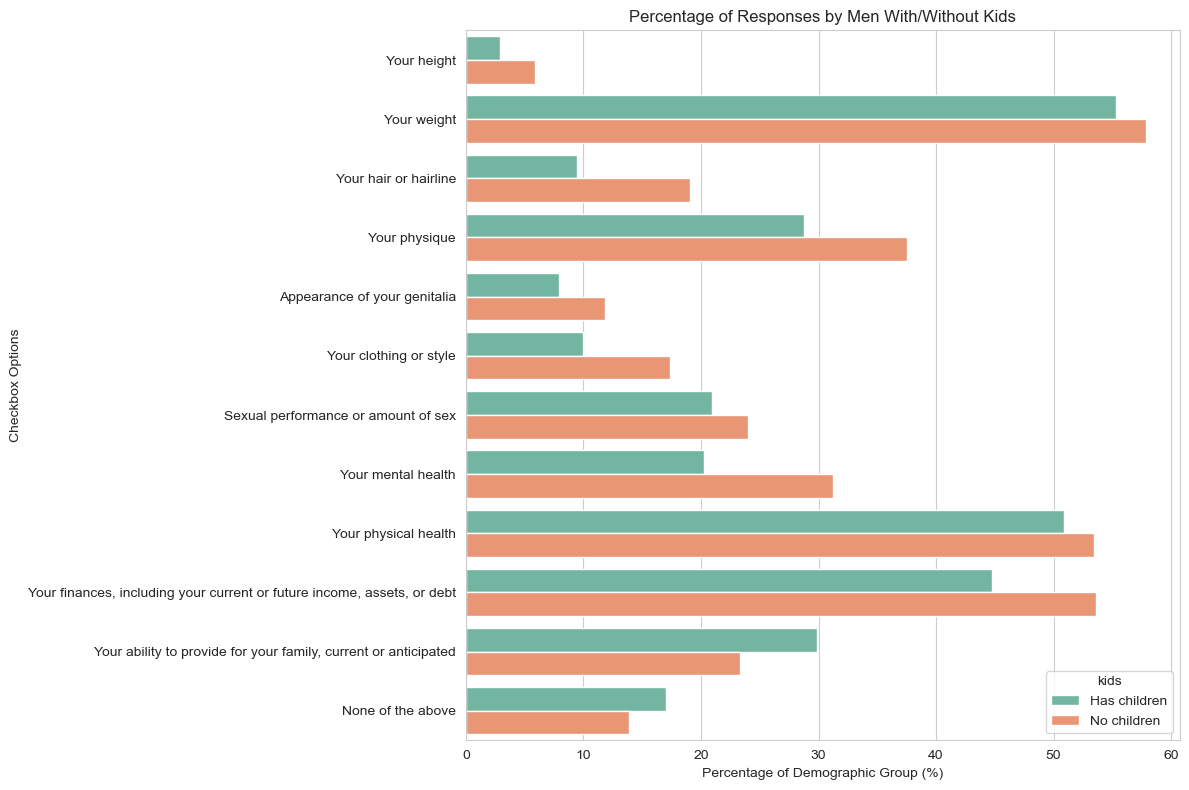

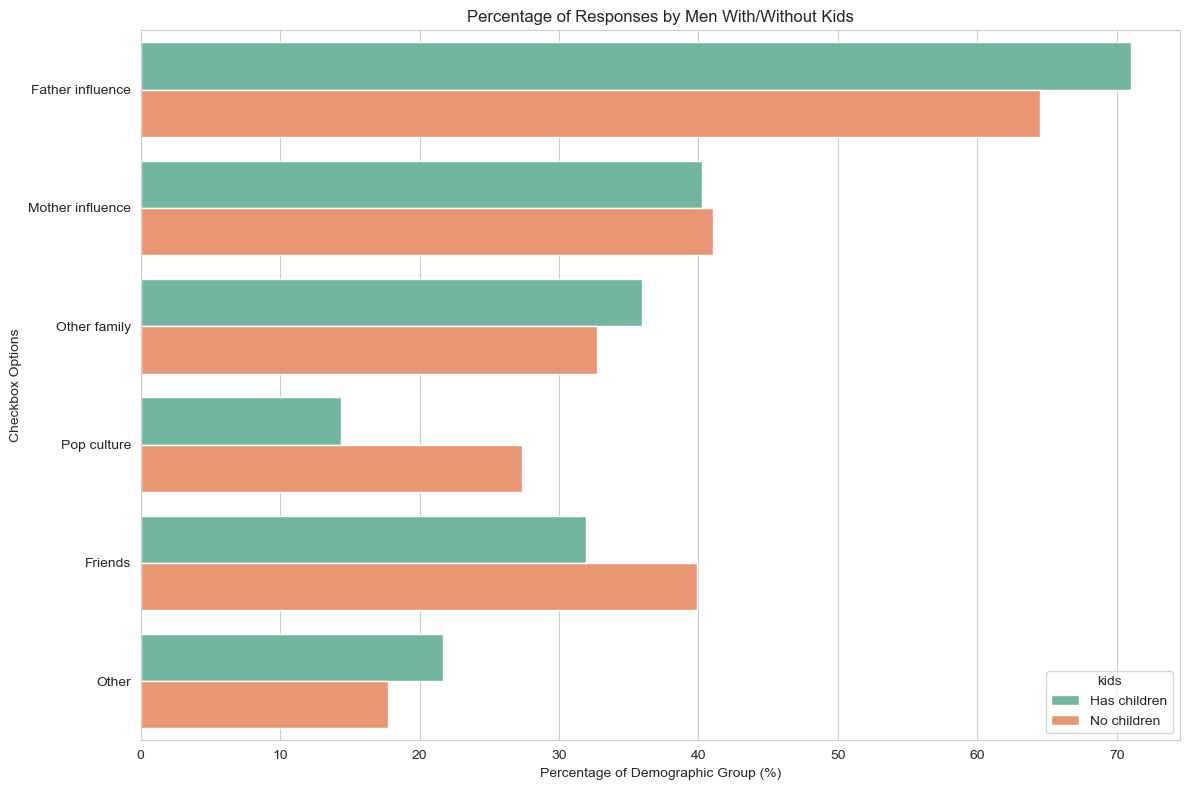

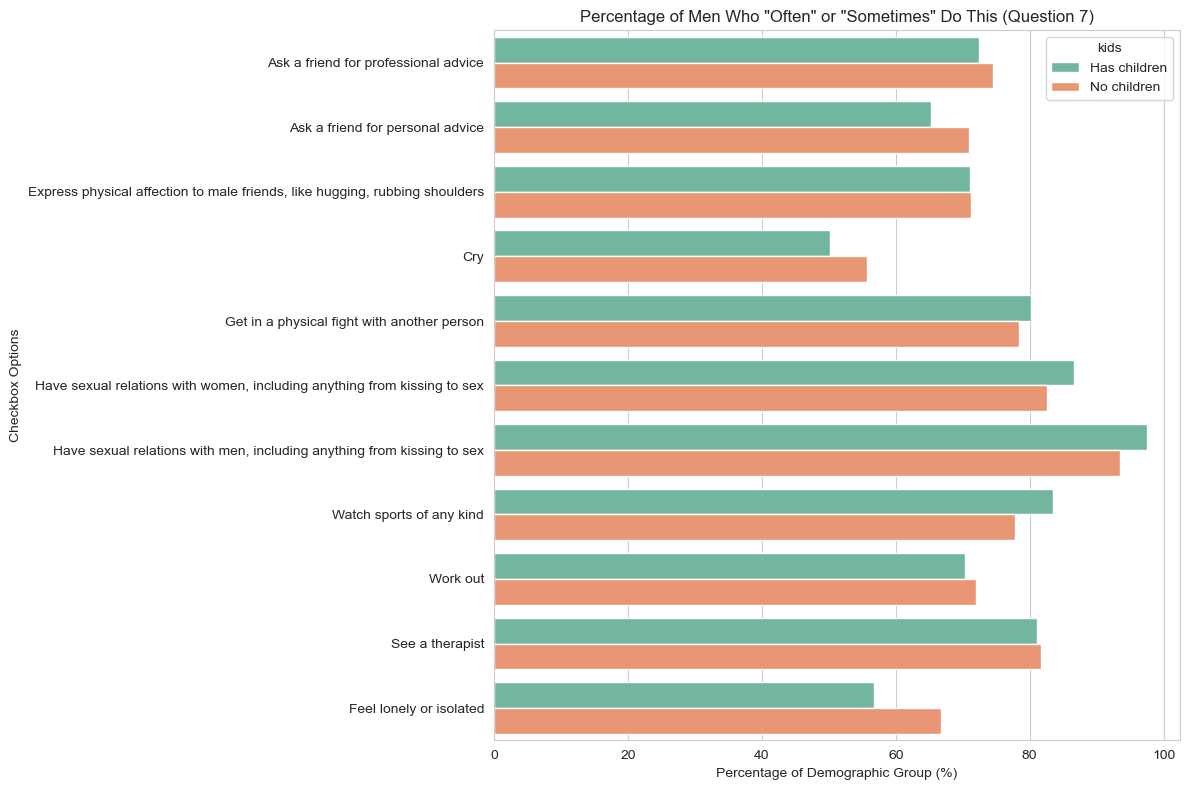

In [21]:
# 1. Define your variables
q8 = ['q0008_0001', 'q0008_0002', 'q0008_0003', 'q0008_0004', 
      'q0008_0005', 'q0008_0006', 'q0008_0007', 'q0008_0008', 
      'q0008_0009', 'q0008_0010', 'q0008_0011', 'q0008_0012']

q8_labels = {
    'q0008_0001': 'Your height',
    'q0008_0002': 'Your weight',
    'q0008_0003': 'Your hair or hairline',
    'q0008_0004': 'Your physique',
    'q0008_0005': 'Appearance of your genitalia',
    'q0008_0006': 'Your clothing or style',
    'q0008_0007': 'Sexual performance or amount of sex',
    'q0008_0008': 'Your mental health',
    'q0008_0009': 'Your physical health',
    'q0008_0010': 'Your finances, including your current or future income, assets, or debt',
    'q0008_0011': 'Your ability to provide for your family, current or anticipated',
    'q0008_0012': 'None of the above'
}


q4 = ['q0004_0001', 'q0004_0002', 'q0004_0003', 'q0004_0004', 'q0004_0005', 'q0004_0006']

q4_labels = {
    'q0004_0001': 'Father influence',
    'q0004_0002': 'Mother influence',
    'q0004_0003': 'Other family', 
    'q0004_0004': 'Pop culture',
    'q0004_0005': 'Friends',
    'q0004_0006': 'Other',
}

q7 = ['q0007_0001', 'q0007_0002', 'q0007_0003', 'q0007_0004', 
      'q0007_0005', 'q0007_0006', 'q0007_0007', 'q0007_0008', 
      'q0007_0009', 'q0007_0010', 'q0007_0011']

q7_labels = {
    'q0007_0001': 'Ask a friend for professional advice',
    'q0007_0002': 'Ask a friend for personal advice',
    'q0007_0003': 'Express physical affection to male friends, like hugging, rubbing shoulders',
    'q0007_0004': 'Cry',
    'q0007_0005': 'Get in a physical fight with another person',
    'q0007_0006': 'Have sexual relations with women, including anything from kissing to sex',
    'q0007_0007': 'Have sexual relations with men, including anything from kissing to sex',
    'q0007_0008': 'Watch sports of any kind',
    'q0007_0009': 'Work out',
    'q0007_0010': 'See a therapist',
    'q0007_0011': 'Feel lonely or isolated'
}



plot_checkbox_percentages(
    df=pd.read_csv('masculinity_survey.csv'), 
    question_cols=q8, 
    labels_dict=q8_labels, 
    title='Percentage of Responses by Men With/Without Kids',
    group_col='kids'
    
)
plot_checkbox_percentages(
    df=pd.read_csv('masculinity_survey.csv'), 
    question_cols=q4, 
    labels_dict=q4_labels, 
    title='Percentage of Responses by Men With/Without Kids',
    group_col='kids'
)


plot_checkbox_percentages(
    df=pd.read_csv('masculinity_survey.csv'), 
    question_cols=q7, 
    labels_dict=q7_labels, 
    group_col='kids', 
    title='Percentage of Men Who "Often" or "Sometimes" Do This (Question 7)',
    values_to_drop=["Never", "Rarely", "No answer"] # Drops these so only Often/Sometimes are counted
)

# The decision tree method


In [22]:
from sklearn.model_selection import train_test_split

random_state=10

q24_encoder = {
    'Never married': 0,
    'Married': 1,
    'Separated': 2,
    'Divorced': 3,
    'Widowed': 4,
    'No answer': 5
}

kids_encoder={'Has children':1,
              'No children':0}

age3_encoder={'18 - 34':0,
             '35 - 64':1,
             '65 and up':2}

features = ['q0024','kids','age3']#features: marital status, has kids, age bracket
target = 'q0001'#target: how masculine do you feel




df = pd.read_csv('masculinity_survey.csv')
df_decision_tree=df[features + [target]].dropna()#drops any NaN in the columns
# possibly should also drop no answer

#turned the catagories into integers because that is how the sklearn decision tree works but it will still essentially work as though its saying has kids/doesnt have kids 
#by saying "kids<0.5" to say if doesn't have kids:true else:false
df_decision_tree['q0024'] = df['q0024'].map(q24_encoder)
df_decision_tree['kids'] = df['kids'].map(kids_encoder)
df_decision_tree['age3'] = df['age3'].map(age3_encoder)



X=df_decision_tree[features]#features data
Y=df_decision_tree[target]#target data (how masucline they feel)  

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=.2,random_state=random_state)#split the data for testing and training 



df_decision_tree.head(15) # what the new data file looks like



,q0024,kids,age3,q0001
0,0,0.0,1,Somewhat masculine
1,4,1.0,2,Somewhat masculine
2,1,1.0,1,Very masculine
3,1,1.0,2,Very masculine
4,0,0.0,1,Very masculine
5,1,1.0,2,Very masculine
6,0,1.0,0,Somewhat masculine
7,1,0.0,2,Somewhat masculine
8,1,1.0,1,Very masculine
9,1,0.0,1,Somewhat masculine


In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report




clf = DecisionTreeClassifier(max_depth=4, random_state=random_state)# intialise model with same random state 
# it should be noted the maximum depth this tree cna make with the features is 9
clf.fit(X_train, Y_train)#train the model
Y_pred = clf.predict(X_test)#make predicitons



### Evaluating the prefomance of the model

In [24]:

# 1 
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")


# 2
Y_train_pred = clf.predict(X_train)
train_accuracy = accuracy_score(Y_train, Y_train_pred)
print(f"training accuracy: {train_accuracy * 100:.2f}%")


# 3
print("Detailed Classification Report:")
print(classification_report(Y_test, Y_pred,zero_division=0)) #print(classification_report(Y_test, Y_pred))

Model Accuracy: 51.55%

training accuracy: 52.18%
Detailed Classification Report:
                      precision    recall  f1-score   support

           No answer       0.00      0.00      0.00         2
Not at all masculine       0.00      0.00      0.00         6
  Not very masculine       0.00      0.00      0.00        34
  Somewhat masculine       0.52      0.97      0.68       165
      Very masculine       0.43      0.05      0.09       115

            accuracy                           0.52       322
           macro avg       0.19      0.20      0.15       322
        weighted avg       0.42      0.52      0.38       322



#### 1 
accuracy against training set
#### 2
I added this part in because I was checking what would happen if I let it grow to its maximum depth and what its accuracy would to which i found it stayed about same plus or minus a percent. So I checked to see if it was just because it wasn't good at predicting the test data, so i check its predicitons against the train set to which it again is only 2% more which shows that with the 36 profiles possible it can make with the features it can only do as good as around 50% which means it might require more features to be accurate which has implications to the question we are trying to solve.
#### 3
classification report which gives a detailed report on how it handled classifying 5 possible catagories


In [25]:
#Just made this to make it easier to follow along the image of the decision tree to understand what the coded descisions mean
features2encoders = {
    "Marital Status (q0024)": q24_encoder,
    "Age Bracket": age3_encoder,
    "Has Kids": kids_encoder
}
for feature,encoder in features2encoders.items():
    print(f"----{feature}----")
    for catagory, code in encoder.items():
        print(f"{catagory} = {code}")

----Marital Status (q0024)----
Never married = 0
Married = 1
Separated = 2
Divorced = 3
Widowed = 4
No answer = 5
----Age Bracket----
18 - 34 = 0
35 - 64 = 1
65 and up = 2
----Has Kids----
Has children = 1
No children = 0


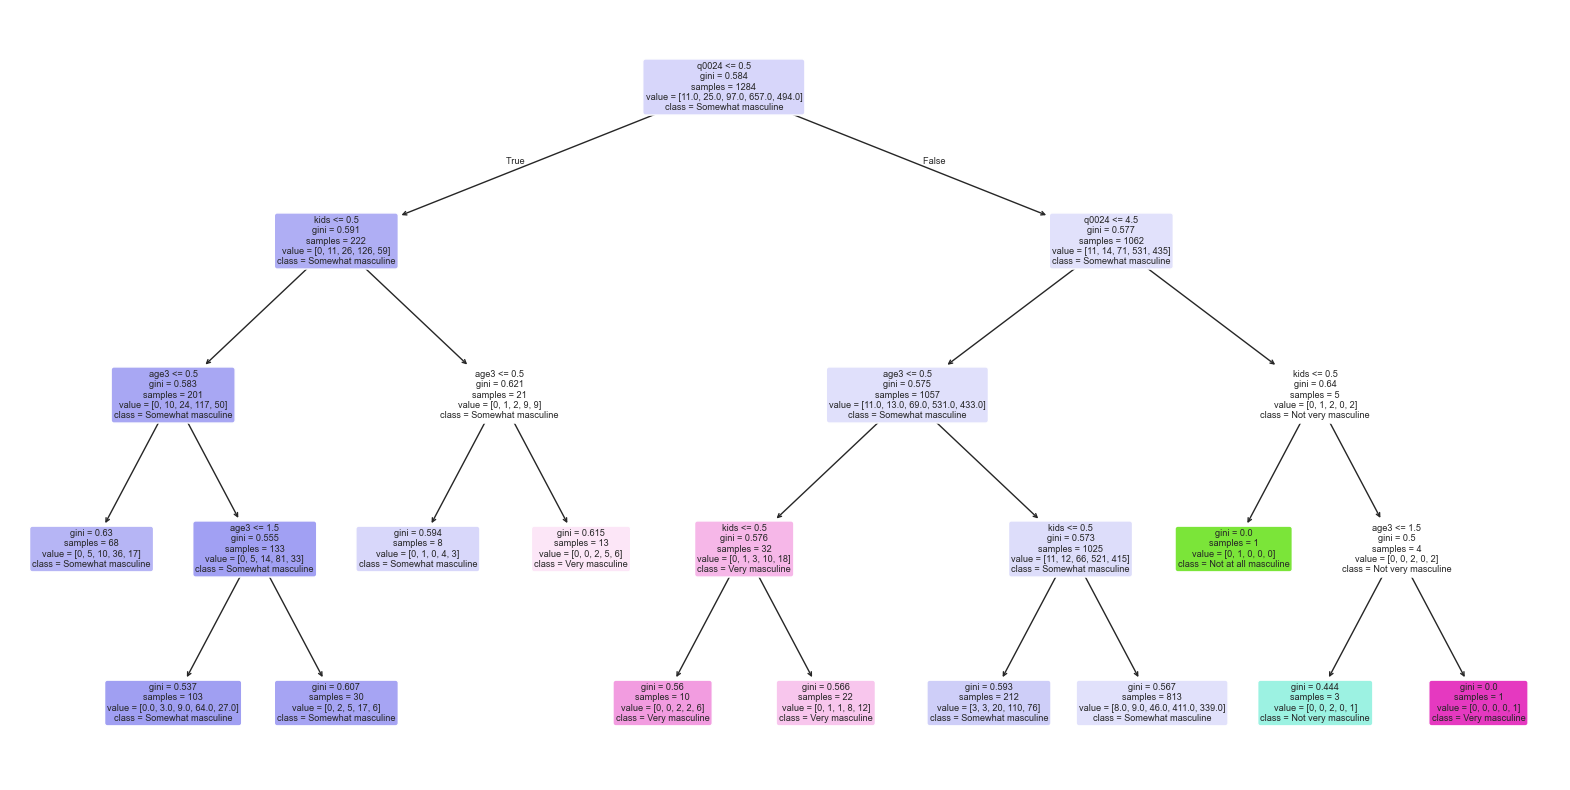

In [27]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(clf, 
          feature_names=features, 
          class_names=df[target].astype('category').cat.categories, 
          filled=True, 
          rounded=True)
plt.show()

## Random Forest Model

To improve our analysis, we used a Random Forest model as a second machine learning method. A Random Forest is made of many decision trees. Each tree learns slightly different patterns from the data, and the final prediction is based on the combined result of all the trees.

We use the same dataset and features as the Decision Tree model to ensure a fair comparison.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

### Training the Model

We train the Random Forest using the same training data as before. The model will attempt to predict masculinity perception based on marital status, whether the respondent has children, and age group.

In [29]:

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,#same complexity as the decision tree for a fair comparison between the two
    random_state=random_state
)

rf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Evaluating the Model

After training, we test the model on unseen data to measure how well it predicts masculinity perception.

In [30]:
Y_pred_rf = rf.predict(X_test)

rf_accuracy = accuracy_score(Y_test, Y_pred_rf)
print(f"Testing Accuracy RF: {rf_accuracy * 100:.2f}%\n")

Y_train_pred_rf = rf.predict(X_train)
train_acc_rf = accuracy_score(Y_train, Y_train_pred_rf)

print(f"Training Accuracy RF: {train_acc_rf * 100:.2f}%")

print("Random Forest Classification Report:")
print(classification_report(Y_test, Y_pred_rf, zero_division=0))

Testing Accuracy RF: 51.55%

Training Accuracy RF: 52.80%
Random Forest Classification Report:
                      precision    recall  f1-score   support

           No answer       0.00      0.00      0.00         2
Not at all masculine       0.00      0.00      0.00         6
  Not very masculine       0.00      0.00      0.00        34
  Somewhat masculine       0.52      0.94      0.67       165
      Very masculine       0.46      0.10      0.16       115

            accuracy                           0.52       322
           macro avg       0.20      0.21      0.17       322
        weighted avg       0.43      0.52      0.40       322



The Random Forest model achieved an accuracy of 51.55%, which is the same as the Decision Tree model. Moreover, the training accuracy for Random Forest was 52.80%, which is very close to the testing accuracy which shows that the model is not overfitting and performs consistently. When comparing both models, there is no real improvement in performance, even though Random Forest is a more complex method that combines multiple trees. 

Looking at the classification report, both models mainly perform well for the “Somewhat masculine” category and struggle to correctly predict the other categories. This is probably due to class imbalance in the dataset, where most responses fall into that one category. Overall, the similarity in results between the Decision Tree and Random Forest suggests that the selected features (marital status, having children, and age) do not fully capture the complexity of masculinity perception, and additional variables may be needed to better model this relationship.

### Feature Importance

This graph shows which features were most important for the Random Forest model when predicting masculinity perception.

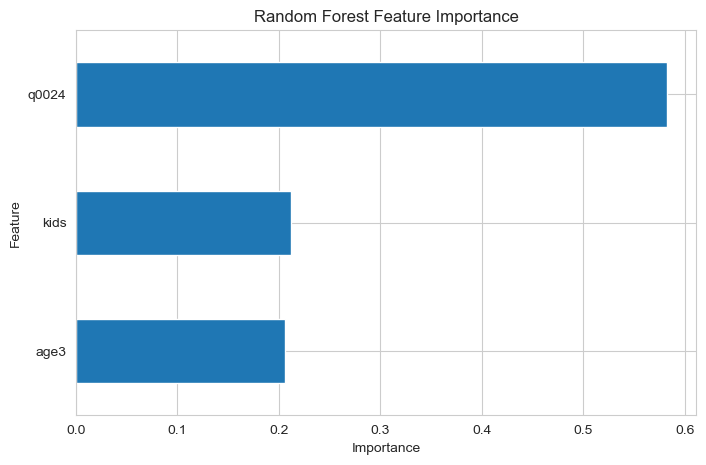

In [31]:
importances = pd.Series(rf.feature_importances_, index=features)

plt.figure(figsize=(8,5))
importances.sort_values().plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

Marital status (q0024) is the most important feature, while kids and age matter much less. However, the model’s low accuracy shows that even this isn’t enough to predict masculinity well.

## Model Improvement 

### Adding an Additional Feature

To improve the model, we added a new feature (q0002), which measures how important it is for respondents to be seen as masculine. This variable is directly related to masculinity perception and may improve prediction performance.

In [32]:
importance_encoder = {
    "Very important": 4,
    "Somewhat important": 3,
    "Not too important": 2,
    "Not at all important": 1,
    "No answer": None
}

df['q0002_encoded'] = df['q0002'].map(importance_encoder)

In [33]:
features_improved = ['q0024', 'kids', 'age3', 'q0002_encoded']
target = 'q0001'

df_improved = df[features_improved + [target]].dropna()

df_improved['q0024'] = df_improved['q0024'].map(q24_encoder)
df_improved['kids'] = df_improved['kids'].map(kids_encoder)
df_improved['age3'] = df_improved['age3'].map(age3_encoder)

df_improved = df_improved.dropna()

In [34]:
X_imp = df_improved[features_improved]
Y_imp = df_improved[target]

X_train_imp, X_test_imp, Y_train_imp, Y_test_imp = train_test_split(
    X_imp, Y_imp, test_size=0.2, random_state=10
)

In [ ]:
rf_imp = RandomForestClassifier(
    n_estimators=100,
    max_depth=4,
    random_state=10,
    class_weight="balanced" #we added this to handle class imbalance since the model keeps predicting only "Somewhat masculine" the most.
)

rf_imp.fit(X_train_imp, Y_train_imp)

,n_estimators,100
,criterion,'gini'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
Y_pred_imp = rf_imp.predict(X_test_imp)
test_acc_imp = accuracy_score(Y_test_imp, Y_pred_imp)
print(f"Improved RF Testing Accuracy: {test_acc_imp * 100:.2f}%")

Y_train_pred_imp = rf_imp.predict(X_train_imp)
train_acc_imp = accuracy_score(Y_train_imp, Y_train_pred_imp)
print(f"Improved RF Training Accuracy: {train_acc_imp * 100:.2f}%\n")

print("Improved RF Classification Report:")
print(classification_report(Y_test_imp, Y_pred_imp, zero_division=0))

Improved RF Testing Accuracy: 47.81%
Improved RF Training Accuracy: 49.06%

Improved RF Classification Report:
                      precision    recall  f1-score   support

           No answer       0.00      0.00      0.00         2
Not at all masculine       0.00      0.00      0.00         6
  Not very masculine       0.09      0.14      0.11        21
  Somewhat masculine       0.58      0.74      0.65       166
      Very masculine       0.77      0.22      0.34       125

            accuracy                           0.48       320
           macro avg       0.29      0.22      0.22       320
        weighted avg       0.61      0.48      0.48       320



The improved Random Forest model got a testing accuracy of 47.81% and a training accuracy of 49.06%, which is actually a bit lower than before. So overall, adding this feature didn’t really improve the accuracy. However, when looking at the classification report, the model does a slightly better job at predicting categories like “Very masculine,” which means it’s not just focusing on the majority class anymore. Even though the accuracy dropped, the predictions are a bit more balanced. This shows that adding a more relevant feature can change how the model behaves, but it still isn’t enough to accurately predict masculinity perception, which is likely more complex than what our variables capture.

# Conclusion & Summary
Throughout the entire project, models and graphs were made to look at factors that led to a masculinity score from men older than 18. After running two machine learning methods (random forest, decision tree) as well as visualizing the data in different graphs, conclusions can be made on how the factors that were looked at lead to a masculinity score. In the models above, the three variables looked at were marital status, age, and if or if not the subject had kids. Later in the random forest model, the variable "how important is it to respondents to be seen as masculine".

To start, it can be seen that only having 3 factors is limiting in predicting masculinity status. While it is believed that the inputs that were put in the models hold a lot of importance in masculinity, it is impossible for just these inputs to show the whole story of somebodies masculinity. With that being said, both models give a testing accuracy of 51.55%. This does give indication of where somebodies masculinity score would be, if someone running an experiment was given the answers to the three variables that we have (age, marital status, if/if not they have kids). It is also shown from our random forest model that marital status holds the most importance, while kids and age have a similar importance on ones masculinity. Later on in the random forest model, it can also be seen that the variable masculinity perception does not improve the model as a whole, but it does improve the model on predicting categories like "Very masculine", and this variable does balance out the results of the model as a whole.

The overall summary of the results shows how complex something like masculinity can be. While the models above do have some accuracy in predicting, they only tell half of the story. In an effort to avoid overfitting and having too complex of a model, models were kept relatively simple and easy to interpret. The results show how much these variables show, and do not show, and why masculinity is a difficult feature to predict.

# Limitations & Recommendations
Since the questionaire for the masculinity survey was 42 questions, it overcrowds the overall study and is a bit confusing to interpret all of the data. The biggest limitation in the models above is the lack of accuracy, but with that being said, it is very hard to say exactly why the model is not as accurate as one would hope. Masculinity is an extremely complex concept, hence why there was 42 questions asking about different topics of ones life to determine their masculinity. To avoid overfitting, there were not many variables added to the models above, and in turn the accuracy was lacking. Even when an additional variable was added, which one would think improves accuracy, the accuracy took a hit and decreased. This shows that more is not always better. The biggest recommendation for a future study would be finding the sweet spot of how many inputs should be added to the models without overfitting to improve the overall accuracy of the models.